In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import equal_weights_baseline, genetic_algorithm, scipy_minimize, riskfolio_minimize, quantum_optimization_function

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Portfolio Optimization using multiple engines

In [90]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [ ]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


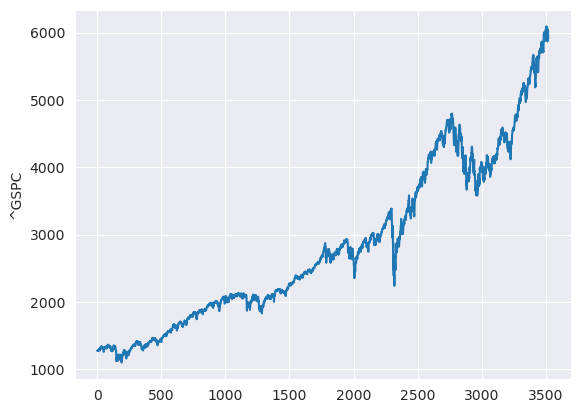

In [92]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [93]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Correlation Analysis

* Determine a set of stocks with minimal correlation

In [94]:
df_corr = source.corr()
df_corr.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.938434,0.972057,0.803930,0.973666,0.944446,0.958391,0.877209,0.950709,0.946486,...,0.915526,0.962450,0.952409,0.840455,-0.192150,0.925082,0.581125,0.957106,0.742547,0.926361
AAPL,0.938434,1.000000,0.925958,0.904199,0.965640,0.912658,0.974905,0.858673,0.957237,0.883810,...,0.954041,0.944027,0.944347,0.799052,-0.274004,0.864298,0.709763,0.932155,0.609996,0.834967
ABT,0.972057,0.925958,1.000000,0.780764,0.974008,0.966874,0.947089,0.840192,0.947416,0.967112,...,0.905557,0.957242,0.959083,0.826124,-0.199613,0.959269,0.502779,0.961910,0.787986,0.938066
ACGL,0.803930,0.904199,0.780764,1.000000,0.859009,0.772929,0.921957,0.746998,0.908116,0.731481,...,0.943648,0.783657,0.889515,0.726342,-0.175307,0.746701,0.854873,0.878777,0.539229,0.617688
ACN,0.973666,0.965640,0.974008,0.859009,1.000000,0.962718,0.975225,0.861665,0.975261,0.940212,...,0.947315,0.970085,0.967641,0.856489,-0.227554,0.926912,0.623003,0.971591,0.727454,0.899654


#### Rank correlation ascending

In [95]:
# rank by correlation
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)
corr_rank

Ticker
TPR       1
BKR       2
GE        3
WYNN      4
DVN       5
       ... 
TXN     435
TEL     436
ITW     437
ICE     438
HD      439
Length: 439, dtype: int64

#### Rank returns descending

In [96]:
# rank by returns
return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
return_rank

Ticker
APA     439
MOS     438
SLB     437
DVN     436
PCG     435
       ... 
TDG       5
FICO      4
AZO       3
BKNG      2
NVR       1
Length: 439, dtype: int64

#### Select sets of 10 and 100 stocks with maximal returns and minimal correlation

In [97]:
select_10 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:11]
select_10

array(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL'], dtype=object)

In [98]:
select_100 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:101]
select_100

array(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL', 'MKTX', 'PWR', 'URI', 'TRGP', 'ZBRA', 'KLAC',
       'NFLX', 'ALGN', 'HUBB', 'AVGO', 'IBM', 'GE', 'BA', 'SPG', 'PH',
       'GNRC', 'ETN', 'BKNG', 'LULU', 'ERIE', 'DECK', 'AZO', 'WAB',
       'EXPE', 'CPAY', 'TDG', 'NVDA', 'BIIB', 'ULTA', 'TFX', 'SNPS',
       'MPWR', 'PODD', 'FDX', 'COST', 'LII', 'VRTX', 'TT', 'BLDR', 'MMM',
       'HUM', 'IT', 'CAT', 'ORLY', 'CAH', 'UAL', 'AMP', 'SBAC', 'UHS',
       'ESS', 'MHK', 'MTB', 'CDNS', 'GILD', 'EOG', 'WST', 'CRL', 'ADBE',
       'COR', 'GPN', 'GS', 'MSI', 'DIS', 'FFIV', 'JBL', 'IDXX', 'DE',
       'CLX', 'PGR', 'AJG', 'KKR', 'FRT', 'ADSK', 'DVA', 'VRSN', 'ANSS',
       'HES', 'XOM', 'CVX', 'MSCI', 'IRM', 'POOL', 'ISRG', 'INCY', 'TTWO',
       'NVR', 'COP', 'LIN', 'BDX', 'FIS'], dtype=object)

Defining Fitness Function for the calculation of Sharpe Ratio. I am using the Portfolio Variance as 

Portfolio variance = w12σ12 + w22σ22 + 2w1w2Cov1,2

### Porfolio Stats

In [99]:
def portfolio_stats(weights, data):

    weights = np.array(weights)
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    # CONSISTENT: Always use log returns, never pct_change()
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

### Fitness function

In [100]:
def fitness_function(weights, data):
    sharpe_ratio, _, _ = portfolio_stats(weights, data)
    return sharpe_ratio


In [101]:
def curried_fitness(weights, data):
    port_return = partial(fitness_function, data)
    return port_return

def minimize_sharpe(weights):
    return -1 * curried_fitness(weights)

### Data generator

Data generator to instantiate blocks on demand

In [102]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [103]:
def backtest(optimization_function, data, benchmark, initial_capital, avg_period, opt_period):
    portfolio_value = initial_capital
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value


    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        df = data.iloc[j:i, :]
        # Use log returns for consistency with optimization functions
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        weights[weights < 0] = 0
        weights /= weights.sum()
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
        except Exception as e:
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = initial_capital * benchmark_cumulative_returns[-1]
        portfolio_value = initial_capital * portfolio_cumulative_returns[-1]
        j += 1

    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    #plt.plot(portfolio_returns, label='Portfolio')
    #plt.plot(benchmark_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [104]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict



### Run Experiment Function

In [105]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    population_size = parameters['population_size']
    num_generations = parameters['num_generations']
    initial_capital = parameters['initial_capital']
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        results_path = results_path_template.format(i)
        if not os.path.exists(results_path):
            try:
                df, df_b = next(datagen)
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                start_time = datetime.now()
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, initial_capital=initial_capital, avg_period=days_to_avg,opt_period=days_to_opt)
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                end_time = datetime.now()
                dt = abs(end_time - start_time)
            except Exception as e: 
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []

            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "population_size": population_size,
                "num_generations": num_generations,
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)

        else:
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']

            # Plot the results
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
            
    return None

### Comparison functions

In [106]:
def multi_comparison(solver_configs, n_periods, title_prefix="Portfolio Optimization", show_benchmark=True):
    """
    Compare multiple portfolio optimization solvers across periods.
    
    Args:
        solver_configs (list): List of dictionaries with 'path_template' and 'name' keys
        n_periods (int): Number of periods to compare
        title_prefix (str): Prefix for plot titles
        show_benchmark (bool): Whether to show benchmark comparison
    """
    
    for period in range(n_periods):
        period_data = []
        benchmark_data = None
        
        # Load data for all solvers for this period
        for config in solver_configs:
            path_template = config['path_template']
            solver_name = config['name']
            file_path = path_template.format(period)
            
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
                    start_date = result_data.get('start_date', 'Unknown')
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Check if portfolio_returns has data (handle NumPy arrays properly)
                    has_portfolio_data = False
                    if portfolio_returns is not None:
                        try:
                            has_portfolio_data = len(portfolio_returns) > 0
                        except TypeError:
                            # Handle case where portfolio_returns is not a sequence
                            has_portfolio_data = portfolio_returns is not None
                    
                    if has_portfolio_data:
                        period_data.append({
                            'name': solver_name,
                            'portfolio_returns': portfolio_returns,
                            'benchmark_returns': benchmark_returns,
                            'start_date': start_date,
                            'execution_time': execution_time,
                            'file_path': file_path
                        })
                        
                        # Store benchmark from first successful load
                        if benchmark_data is None and benchmark_returns is not None:
                            try:
                                if len(benchmark_returns) > 0:
                                    benchmark_data = benchmark_returns
                            except (TypeError, AttributeError):
                                pass
                        
                        logger.info(f'Period {period}: Loaded {solver_name} (exec_time: {execution_time:.2f}s)')
                    else:
                        logger.warning(f'Period {period}: {solver_name} has no portfolio returns data')
                else:
                    logger.warning(f'Period {period}: Could not load {solver_name} from {file_path}')
                    
            except Exception as e:
                logger.error(f'Period {period}: Error loading {solver_name} from {file_path}: {e}')
        
        # Plot results if we have any data
        if period_data:
            plt.figure(figsize=(15, 8))
            
            # Color palette for better distinction
            colors = plt.cm.Set1(np.linspace(0, 1, len(period_data)))
            
            # Plot portfolio returns for each solver
            for i, data in enumerate(period_data):
                plt.plot(data['portfolio_returns'], 
                        label=f"{data['name']} (t={data['execution_time']:.1f}s)", 
                        color=colors[i], 
                        linewidth=2, 
                        alpha=0.8)
            
            # Plot benchmark if available and requested
            if show_benchmark and benchmark_data is not None:
                plt.plot(benchmark_data, 
                        label='S&P 500 Benchmark', 
                        linestyle='--', 
                        color='black', 
                        linewidth=2, 
                        alpha=0.7)
            
            plt.title(f'{title_prefix} Comparison - Period {period}\\n'
                     f'Start Date: {period_data[0]["start_date"]} | Solvers: {len(period_data)}')
            plt.xlabel('Trading Days')
            plt.ylabel('Cumulative Returns')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\\nPeriod {period} Summary:")
            print("-" * 50)
            for data in period_data:
                try:
                    final_return = data['portfolio_returns'][-1] if len(data['portfolio_returns']) > 0 else 0
                except (IndexError, TypeError):
                    final_return = 0
                print(f"{data['name']:<25}: {final_return:>8.4f} ({data['execution_time']:>6.2f}s)")
            if benchmark_data is not None:
                try:
                    benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
                except (IndexError, TypeError):
                    benchmark_final = 0
                print(f"{'Benchmark':<25}: {benchmark_final:>8.4f}")
            print()
            
        else:
            logger.warning(f'No data available for any solver in period {period}')

def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()


### GA and Global Parameters

#### From Hyperparameter Optimization

* pop size: 100
* n gen: 100
* mut: 0.1
* elit: 0.5

<Axes: xlabel='ds'>

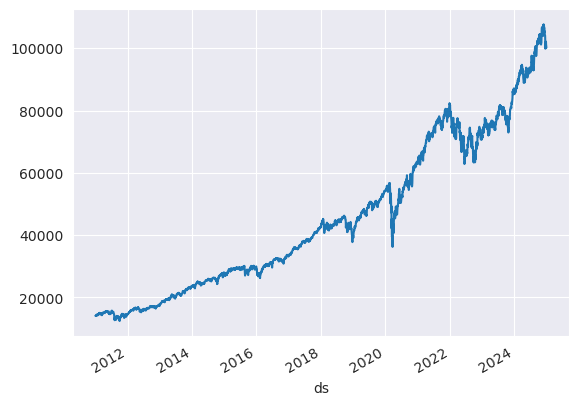

In [107]:
source.sum(axis=1).plot()

total sum if we consider a portfolio with one share per ticker then we get around $100,000 by 2024. We need to set initial_capital to a higher value, 1,000,000 in this case.

In [108]:
parameters = {
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "initial_capital": 1_000_000,
}

### Easy Test: Optimization with 10 stocks

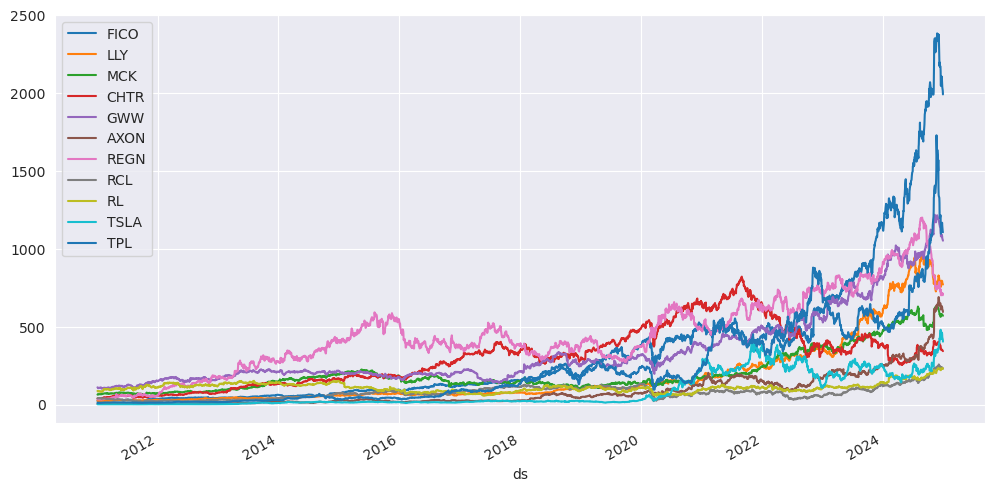

In [109]:
data_10 = source[select_10]
sns.set_style('darkgrid')
data_10.plot(figsize=(12,6))
plt.legend(loc='upper left')
plt.show()

In [110]:
df = data_10.copy()
days_to_avg = parameters['days_to_avg']
display(df.head())
print(f'initial date: {df.iloc[days_to_avg+1, :].index}')

Ticker,FICO,LLY,MCK,CHTR,GWW,AXON,REGN,RCL,RL,TSLA,TPL
ds,,,,,,,,,,,
2011-01-03,23.337875,24.383286,63.808739,38.459999,110.267799,5.00,33.776596,39.921806,87.635155,1.774667,10.710283
2011-01-04,22.812870,24.404190,64.355370,39.599998,110.022827,4.77,33.217312,40.473835,85.022339,1.778000,10.739388
2011-01-05,22.822775,24.230032,64.812325,39.570000,109.588188,4.88,33.247276,40.908760,84.975266,1.788667,10.704462
2011-01-06,22.902021,24.341486,67.079399,39.220001,105.621284,4.77,34.265968,40.030552,84.692795,1.858667,10.751030
2011-01-07,22.307678,24.313623,66.308769,39.180000,104.783623,4.79,34.056232,40.139271,83.766922,1.882667,10.748118


initial date: Index(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL'],
      dtype='object', name='Ticker')


In [111]:
df.iloc[days_to_avg+1:, :].index[0]

Timestamp('2011-02-16 00:00:00')

#### GA 

#### Equal Weights Baseline

In [ ]:
opt_fun_ew = partial(equal_weights_baseline)
results_path_ew_10 = '../../results/sharpe_risk_neutral/results_10_{}_ew.pkl'
_ = run_experiment(results_path_ew_10, data_10, benchmark, opt_fun_ew, parameters)

In [ ]:
opt_fun_ga = partial(genetic_algorithm, 
                  fitness_function=fitness_function, 
                  population_size=parameters["population_size"], 
                  num_generations=parameters["num_generations"], 
                  mutation_rate=parameters["mutation_rate"], 
                  elitism=parameters["elitism"])

In [ ]:
results_path_ga_10 = '../../results/sharpe_risk_neutral/results_10_{}_ga.pkl'
_ = run_experiment(results_path_ga_10, data_10, benchmark, opt_fun_ga, parameters)

#### Brute Force

In [ ]:
opt_fun_bf = partial(scipy_minimize, fitness_function=fitness_function)
results_path_bf_10 = '../../results/sharpe_risk_neutral/results_10_{}_bf.pkl'
_ = run_experiment(results_path_bf_10, data_10, benchmark, opt_fun_bf, parameters)

#### HRP

In [ ]:
opt_fun_hrp = partial(riskfolio_minimize)
results_path = '../../results/sharpe_risk_neutral/results_10_{}_hrp.pkl'
_ = run_experiment(results_path, data_10, benchmark, opt_fun_hrp, parameters)

#### Trio comparison for Easy Test

In [ ]:
# Complete comparison including Quantum for Easy Test (10 stocks)
easy_test_solvers = [
    {'path_template': '../../results/sharpe_risk_neutral/results_10_{}_ew.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/sharpe_risk_neutral/results_10_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/sharpe_risk_neutral/results_10_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/sharpe_risk_neutral/results_10_{}_hrp.pkl', 'name': 'Hierarchical Risk Parity'},
]

n_periods = parameters['n_periods']
multi_comparison(easy_test_solvers, n_periods, "All Optimization Methods (10 Stocks)")

# Generate performance summary
print("\\n" + "="*80)
print("PERFORMANCE SUMMARY - All Methods (10 Stocks)")
print("="*80)
summary_df = performance_summary(easy_test_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")

### Medium test: Optimization with 100 stocks

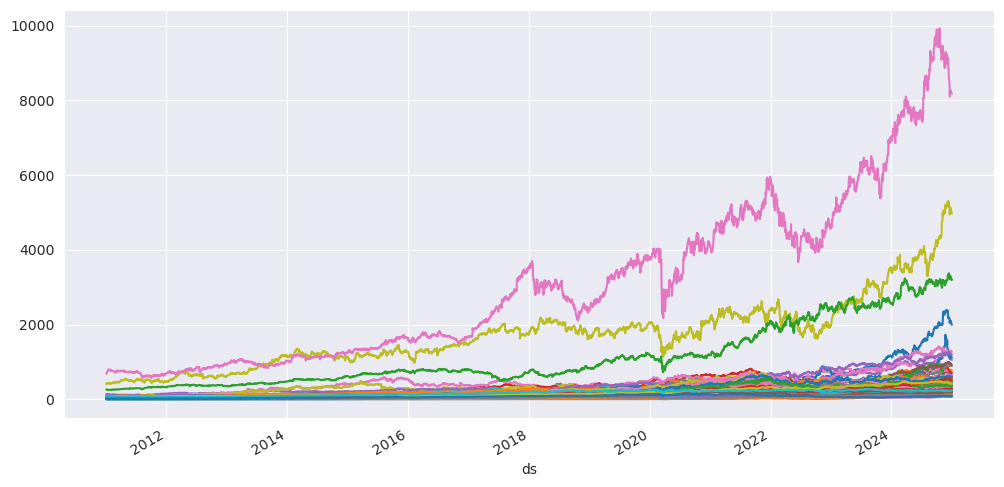

In [117]:
data_100 = source[select_100]
sns.set_style('darkgrid')
data_100.plot(figsize=(12,6))
plt.legend().remove()
plt.show()

#### GA

#### Equal Weights Baseline

In [ ]:
results_path_ew_100 = '../../results/sharpe_risk_neutral/results_100_{}_ew.pkl'
_ = run_experiment(results_path_ew_100, data_100, benchmark, opt_fun_ew, parameters)

In [ ]:
results_path_ga_100 = '../../results/sharpe_risk_neutral/results_100_{}_ga.pkl'
_ = run_experiment(results_path_ga_100, data_100, benchmark, opt_fun_ga, parameters)

### BF

In [ ]:
results_path_bf_100 = '../../results/sharpe_risk_neutral/results_100_{}_bf.pkl'
_ = run_experiment(results_path_bf_100, data_100, benchmark, opt_fun_bf, parameters)

#### HRP

In [ ]:
results_path_hrp_100 = '../../results/sharpe_risk_neutral/results_100_{}_hrp.pkl'
_ = run_experiment(results_path_hrp_100, data_100, benchmark, opt_fun_hrp, parameters)

#### Pair comparison for Medium test

In [ ]:
# Complete comparison including Quantum for Medium Test (100 stocks)
medium_test_solvers = [
    {'path_template': '../../results/sharpe_risk_neutral/results_100_{}_ew.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/sharpe_risk_neutral/results_100_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/sharpe_risk_neutral/results_100_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/sharpe_risk_neutral/results_100_{}_hrp.pkl', 'name': 'Hierarchical Risk Parity'},
]

n_periods = parameters['n_periods']
multi_comparison(medium_test_solvers, n_periods, "All Optimization Methods (100 Stocks)")

# Generate performance summary
print("\\n" + "="*80)
print("PERFORMANCE SUMMARY - All Methods (100 Stocks)")
print("="*80)
summary_df = performance_summary(medium_test_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
    
    # Traditional vs Quantum comparison
    traditional_methods = summary_df[summary_df['Solver'].isin(['Genetic Algorithm', 'Scipy SLSQP', 'Hierarchical Risk Parity'])]
    quantum_methods = summary_df[summary_df['Solver'].str.contains('Quantum')]
    
    if not traditional_methods.empty and not quantum_methods.empty:
        print("\\nTraditional vs Quantum Analysis:")
        print("-" * 40)
        print(f"Traditional avg return: {traditional_methods['Avg_Return'].mean():.4f}")
        print(f"Quantum avg return: {quantum_methods['Avg_Return'].mean():.4f}")
        print(f"Traditional avg time: {traditional_methods['Avg_Time'].mean():.2f}s")
        print(f"Quantum avg time: {quantum_methods['Avg_Time'].mean():.2f}s")
else:
    print("No summary data available")

### Full dataset

### GA

#### Equal Weights Baseline

In [ ]:
results_path_ew_full = '../../results/sharpe_risk_neutral/results_full_{}_ew.pkl'
_ = run_experiment(results_path_ew_full, source, benchmark, opt_fun_ew, parameters)

In [ ]:
results_path_ga_full = '../../results/sharpe_risk_neutral/results_full_{}_ga.pkl'
_ = run_experiment(results_path_ga_full, source, benchmark, opt_fun_ga, parameters)

### BF

In [ ]:
results_path_bf_full = '../../results/sharpe_risk_neutral/results_full_{}_bf.pkl'
_ = run_experiment(results_path_bf_full, source, benchmark, opt_fun_bf, parameters)

#### HRP

In [ ]:
results_path_hrp_full = '../../results/sharpe_risk_neutral/results_full_{}_hrp.pkl'
_ = run_experiment(results_path_hrp_full, source, benchmark, opt_fun_hrp, parameters)

### Comparison for full dataset

In [ ]:
# Comprehensive comparison of ALL optimization methods for Full Dataset including Quantum
full_dataset_solvers = [
    {'path_template': '../../results/sharpe_risk_neutral/results_full_{}_ew.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/sharpe_risk_neutral/results_full_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/sharpe_risk_neutral/results_full_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/sharpe_risk_neutral/results_full_{}_hrp.pkl', 'name': 'Hierarchical Risk Parity'},
]

n_periods = parameters['n_periods']
multi_comparison(full_dataset_solvers, n_periods, "All Optimization Methods (Full Dataset)")

# Generate comprehensive performance summary
print("\\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - All Methods (Full Dataset)")
print("="*100)
summary_df = performance_summary(full_dataset_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")

## Wide dataset

In [ ]:
source_path_extended = '../../data/etfs_close.pkl'

In [127]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [128]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [129]:
df = source_wide.copy()
days_to_avg = parameters['days_to_avg']
display(df.head())
print(f'initial date: {df.iloc[days_to_avg+1, :].index}')

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


initial date: Index(['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK',
       ...
       'XLP', 'XLU', 'XLV', 'XLY', 'XME', 'XOP', 'XPH', 'XRT', 'XSD', 'XTNT'],
      dtype='object', name='Ticker', length=680)


<Axes: xlabel='ds'>

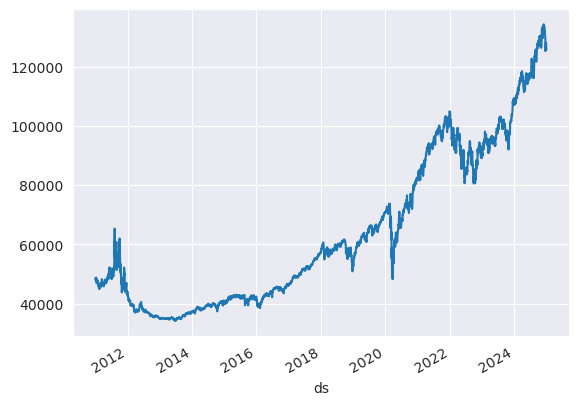

In [130]:
df.sum(axis=1).plot()

### GA

#### Equal Weights Baseline

In [ ]:
results_path_ew_wide = '../../results/sharpe_risk_neutral/results_wide_{}_ew.pkl'
_ = run_experiment(results_path_ew_wide, df, benchmark, opt_fun_ew, parameters)

In [ ]:
results_path_ga_wide = '../../results/sharpe_risk_neutral/results_wide_{}_ga.pkl'
_ = run_experiment(results_path_ga_wide, df, benchmark, opt_fun_ga, parameters)

### BF

In [ ]:
opt_fun_bf = partial(scipy_minimize, fitness_function=fitness_function)
results_path_bf = '../../results/sharpe_risk_neutral/results_wide_{}_bf.pkl'
_ = run_experiment(results_path_bf, df, benchmark, opt_fun_bf, parameters)

### HRP

In [ ]:
opt_fun_hrp = partial(riskfolio_minimize)
results_path = '../../results/sharpe_risk_neutral/results_wide_{}_hrp.pkl'
_ = run_experiment(results_path, df, benchmark, opt_fun_hrp, parameters)

### Method comparison 

In [ ]:
# Comprehensive comparison of ALL optimization methods for Wide Dataset including Quantum
wide_dataset_solvers = [
    {'path_template': '../../results/sharpe_risk_neutral/results_wide_{}_ew.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/sharpe_risk_neutral/results_wide_{}_ga.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/sharpe_risk_neutral/results_wide_{}_bf.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/sharpe_risk_neutral/results_wide_{}_hrp.pkl', 'name': 'Hierarchical Risk Parity'},
]

n_periods = parameters['n_periods']
multi_comparison(wide_dataset_solvers, n_periods, "All Optimization Methods (Wide Dataset - Stocks + ETFs)")

# Generate comprehensive performance summary
print("\\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - All Methods (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(wide_dataset_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")